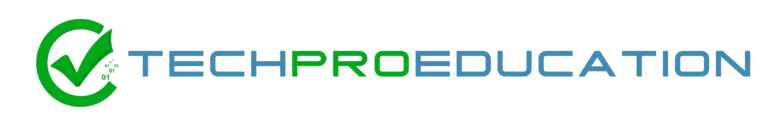

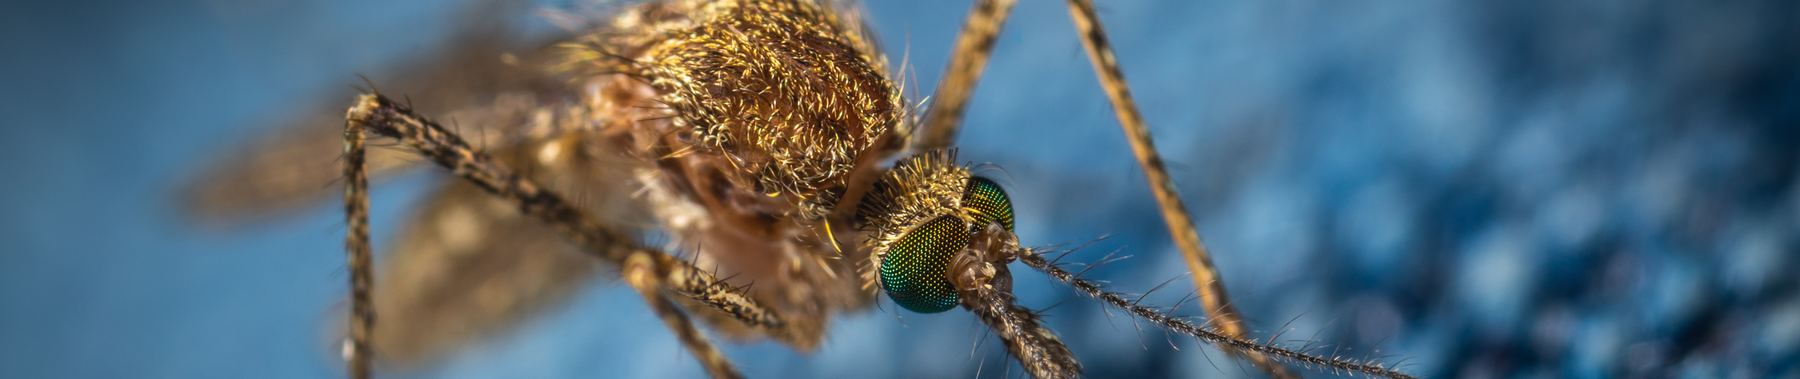

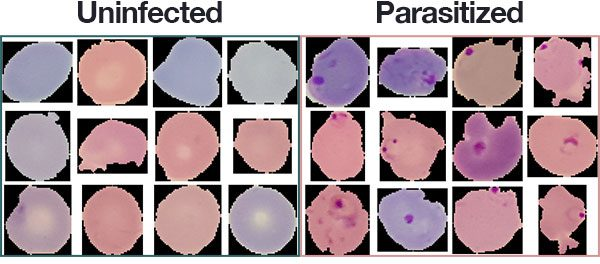

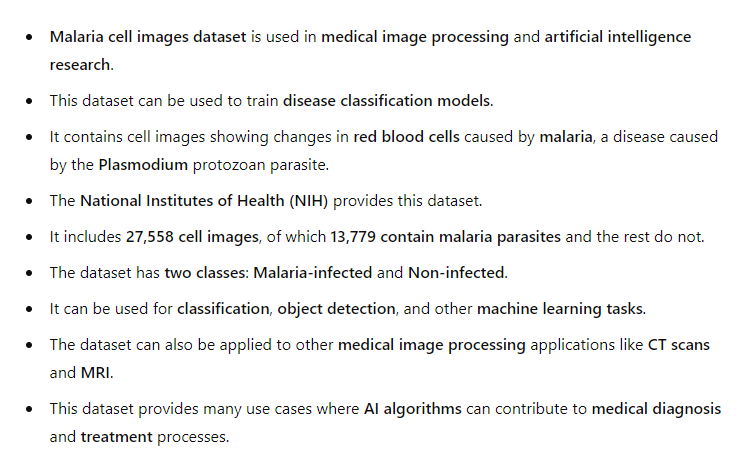

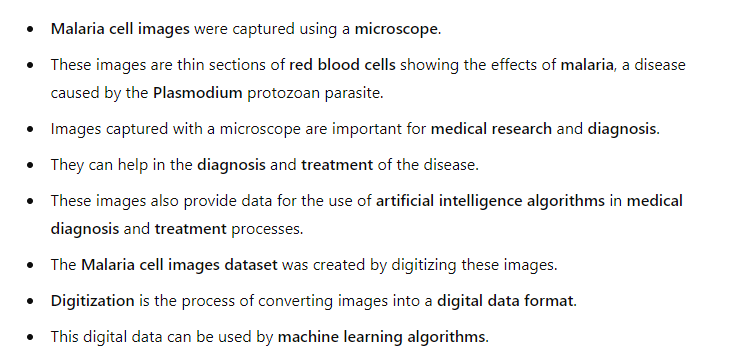

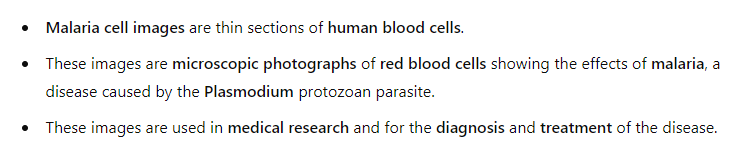


# CNN With Custom Images: Malaria Cell Images Dataset

The dataset contains 2 folders - Infected - Uninfected

And a total of 27,558 images.


This Dataset was taken from the official NIH Website: https://ceb.nlm.nih.gov/repositories/malaria-datasets/ 

Kaggle: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria

In [1]:
import os # file and operating system operations
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Hide all warnings
import warnings
warnings.filterwarnings("ignore")

# Hide deprecated warnings in Keras and TensorFlow
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

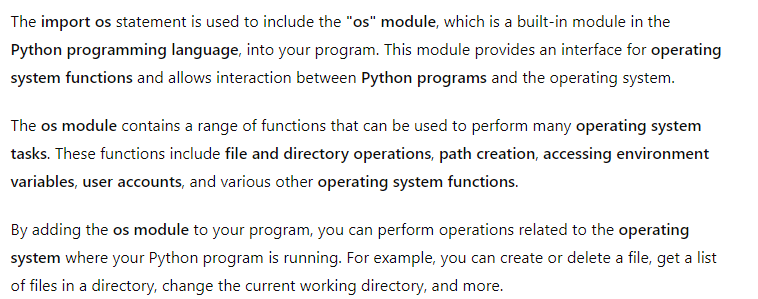

In [3]:
os.getcwd() # get current working directory
# before it used to be pwd as print working directory
# if the image is in the same path then nice, otherwise we have to give it's path

'C:\\Users\\jawed\\Desktop\\B287 DL\\04 CNN\\Repo Notebooks\\05 Malaria'

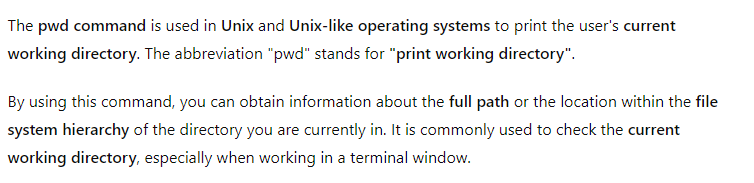

In [4]:
my_data= 'cell_images' # It connects to the image file in the folder specified with pwd. 

# if you want to connect to a RAR file, we can use another application to make this connection

In [5]:
os.listdir(my_data) # It shows which folders are in the "cell_images" file.

['test', 'train']

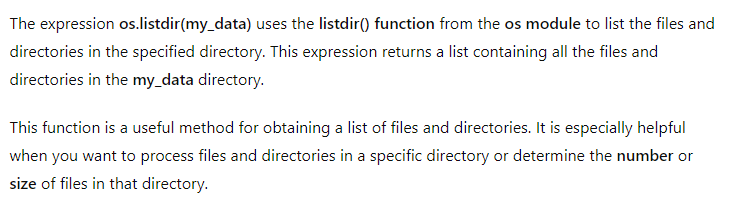

In [6]:
train_path = my_data+'/train/'# Links to "train" data in the "cell_images" file.
test_path = my_data+'/test/' # Links to "test" data in the "cell_images" file.

In [7]:
os.listdir(train_path) # os: operation system. Shows items in the "train_path"

['parasitized', 'uninfected']

In [8]:
os.listdir(test_path) # os: operation system. Shows items in the "test_path"

['parasitized', 'uninfected']

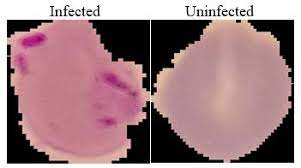

In [9]:
os.listdir(train_path+'parasitized')[:30] # It selects 30 observations for the "parasitized" parts in the "train" cells.

['C100P61ThinF_IMG_20150918_144104_cell_162.png',
 'C100P61ThinF_IMG_20150918_144104_cell_163.png',
 'C100P61ThinF_IMG_20150918_144104_cell_164.png',
 'C100P61ThinF_IMG_20150918_144104_cell_165.png',
 'C100P61ThinF_IMG_20150918_144104_cell_166.png',
 'C100P61ThinF_IMG_20150918_144104_cell_167.png',
 'C100P61ThinF_IMG_20150918_144104_cell_168.png',
 'C100P61ThinF_IMG_20150918_144104_cell_169.png',
 'C100P61ThinF_IMG_20150918_144104_cell_170.png',
 'C100P61ThinF_IMG_20150918_144104_cell_171.png',
 'C100P61ThinF_IMG_20150918_144348_cell_138.png',
 'C100P61ThinF_IMG_20150918_144348_cell_139.png',
 'C100P61ThinF_IMG_20150918_144348_cell_140.png',
 'C100P61ThinF_IMG_20150918_144348_cell_141.png',
 'C100P61ThinF_IMG_20150918_144348_cell_142.png',
 'C100P61ThinF_IMG_20150918_144348_cell_143.png',
 'C100P61ThinF_IMG_20150918_144823_cell_157.png',
 'C100P61ThinF_IMG_20150918_144823_cell_158.png',
 'C100P61ThinF_IMG_20150918_144823_cell_159.png',
 'C100P61ThinF_IMG_20150918_144823_cell_160.png',


In [10]:
os.listdir(train_path+'parasitized')[17] # It shows 18th observations for the "parasitized" parts in the "train" cells.

'C100P61ThinF_IMG_20150918_144823_cell_158.png'

In [11]:
para_cell = train_path+'parasitized'+'/C100P61ThinF_IMG_20150918_144823_cell_158.png'

In [12]:
imread(para_cell)            # "imread" returns a numpy array containing the image's pixel values.

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)

In [13]:
para_img= imread(para_cell) # It assigns the image read with "imread" to the "paralise image: para_img" variable.

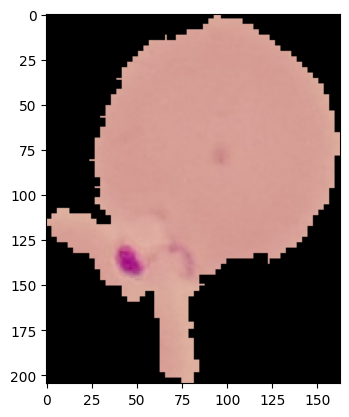

In [14]:
plt.imshow(para_img);

In [15]:
para_img.shape # Size 205x163 and RGB (coloured image).

(205, 163, 3)

**Note:** In CNN it is recommended for images to be in square format like 20x20 or 32x32.

In [16]:
os.listdir(train_path+'uninfected')[:20] # Returns 20 uninfected images from the same folder.

['C100P61ThinF_IMG_20150918_144104_cell_128.png',
 'C100P61ThinF_IMG_20150918_144104_cell_131.png',
 'C100P61ThinF_IMG_20150918_144104_cell_144.png',
 'C100P61ThinF_IMG_20150918_144104_cell_21.png',
 'C100P61ThinF_IMG_20150918_144104_cell_25.png',
 'C100P61ThinF_IMG_20150918_144104_cell_48.png',
 'C100P61ThinF_IMG_20150918_144104_cell_65.png',
 'C100P61ThinF_IMG_20150918_144348_cell_120.png',
 'C100P61ThinF_IMG_20150918_144348_cell_125.png',
 'C100P61ThinF_IMG_20150918_144348_cell_131.png',
 'C100P61ThinF_IMG_20150918_144348_cell_2.png',
 'C100P61ThinF_IMG_20150918_144348_cell_25.png',
 'C100P61ThinF_IMG_20150918_144348_cell_40.png',
 'C100P61ThinF_IMG_20150918_144348_cell_71.png',
 'C100P61ThinF_IMG_20150918_144823_cell_126.png',
 'C100P61ThinF_IMG_20150918_144823_cell_127.png',
 'C100P61ThinF_IMG_20150918_144823_cell_139.png',
 'C100P61ThinF_IMG_20150918_144823_cell_142.png',
 'C100P61ThinF_IMG_20150918_144823_cell_151.png',
 'C100P61ThinF_IMG_20150918_144823_cell_21.png']

In [17]:
uninfected_cell_path = train_path+'uninfected/'+os.listdir(train_path+'uninfected')[7]
# let's select a cell

In [18]:
uninfected_cell_path

'cell_images/train/uninfected/C100P61ThinF_IMG_20150918_144348_cell_120.png'

In [19]:
imread(uninfected_cell_path)

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)

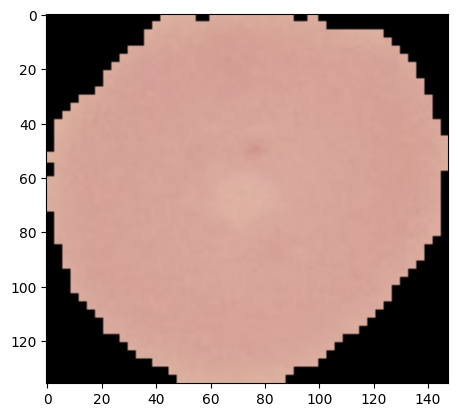

In [20]:
uninfected_cell = imread(uninfected_cell_path)
plt.imshow(uninfected_cell);

**Let's check how many images there are.**

In [21]:
len(os.listdir(train_path+'parasitized'))

12480

In [22]:
len(os.listdir(train_path+'uninfected'))

12480

* It is a **balanced** data.

**Let's find out the average dimensions of these images.**

In [23]:
uninfected_cell.shape  # Index 7

(136, 148, 3)

In [24]:
para_img.shape    # Index 17.  !!! Sizes are different !!!

(205, 163, 3)

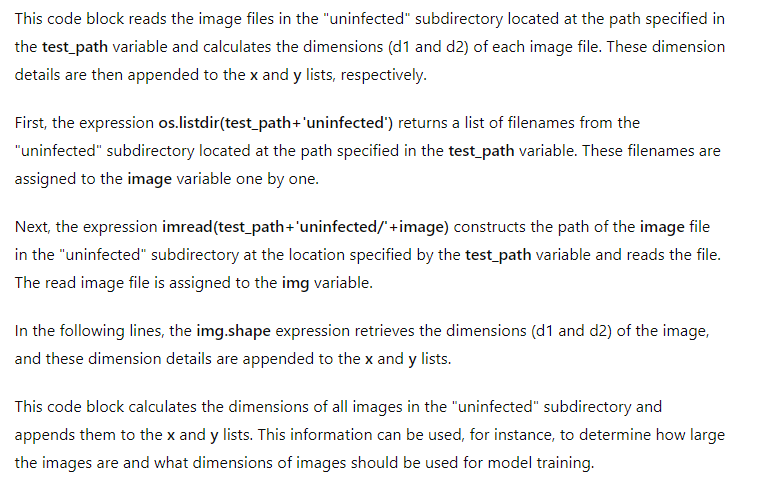

In [25]:
x = []
y = []
for image in os.listdir(test_path+'uninfected'):
    
    img = imread(test_path+'uninfected/'+image)
    d1,d2,_ = img.shape  # d1 and d2 necessary, but last one (RGB) is not. SO, we can use "_" for that unimportant data. 
    x.append(d1)
    y.append(d2)

In [26]:
y[:20]

[118,
 145,
 151,
 145,
 139,
 136,
 160,
 121,
 142,
 121,
 100,
 151,
 139,
 151,
 112,
 124,
 145,
 115,
 166,
 130]

In [27]:
x[:20]

[118,
 172,
 130,
 163,
 172,
 139,
 151,
 160,
 145,
 127,
 121,
 154,
 145,
 127,
 154,
 151,
 148,
 130,
 160,
 136]

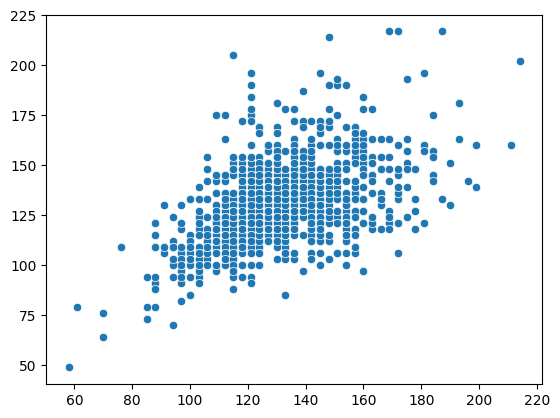

In [28]:
sns.scatterplot(x=x,y=y); # For see average size of images.

In [29]:
np.mean(x)

np.float64(130.92538461538462)

In [30]:
np.mean(y)

np.float64(130.75)

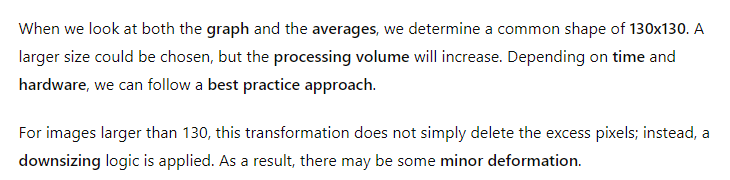

In [31]:
image_shape = (130,130,3) # For convert all data to same size
# setting same size for all images by mean of both pixels

## Preparing the Data for the model

In [32]:
uninfected_cell.max()

np.float32(0.88235295)

In [33]:
para_img.max()

np.float32(0.8980392)

While we would normally expect min=0 and max=255, we see that a scaling process has been applied earlier. No need for scaling if the images are already scaled or in same scale.

### Image Generator

**NOTE:** Applying various distortions to the image, such as rotating, zooming, stretching, and stretching, **facilitates learning.** Therefore, we will distort the images below. The image is inserted into the model in different ways. The number of images doesn't increase here; it just hinders the model. **Instead of 27,000 images, it's as if 90,000 images were inserted.**

We manipulate the code below. **We generate synthetic data,** but only in a way that will be used in the model's input section. It rotates the images to a maximum of 15 degrees, increases the width by 10%, etc. etc. In this process, the number of images in the CNN does not increase, but the CV will increase. Using the values below is **Best Practice..**

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [35]:
image_gen = ImageDataGenerator(rotation_range=15, 
                               width_shift_range=0.10, 
                               height_shift_range=0.10, 
                               #rescale=1/255,           ==> data was scaled before
                               shear_range=0.1, 
                               zoom_range=0.1, 
                               horizontal_flip=True, 
                               fill_mode='nearest')

This process does not concretely **replicate** the existing data but provides **diversity** through various **transformations** as it goes to the model.

This code creates an `ImageDataGenerator` object used for **data augmentation**. The operation performed here is **applying random transformations (rotation, shifting, cropping, zoom, horizontal flipping, etc.) on images from the existing dataset to generate different variations that will be used in model training.**

**Does the number of data increase?**

* **It does not physically increase the number of data.** In other words, the number of original image files on the disk remains unchanged.
* However, during training, at each epoch, the `ImageDataGenerator` **dynamically applies these transformations to generate different versions.**
* As a result, the model **encounters different variations at each training step, and thus, the "effective" number of data seems to increase.**
* This allows the model to see more diversity, reduces overfitting, and increases generalization capacity.

In short:

With this code, **the physical number of data doesn't increase, but the diversity of data used in training increases.** This makes the model more robust and generalized.


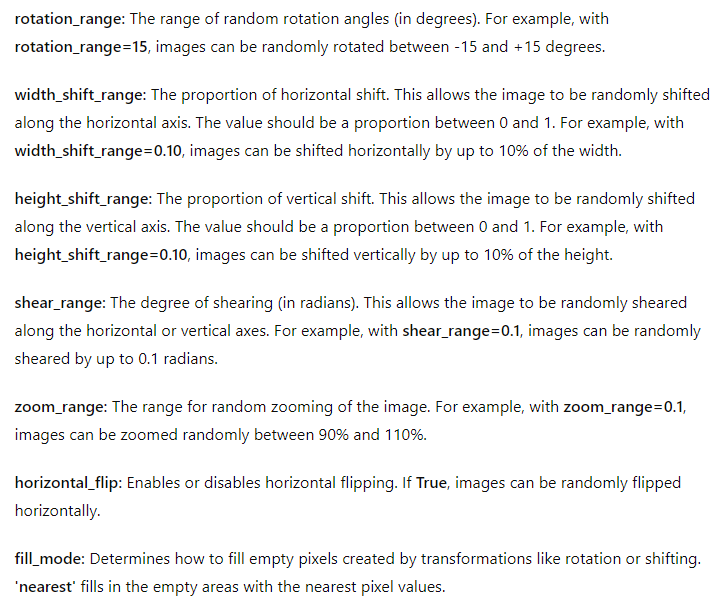

#### An example for image generation

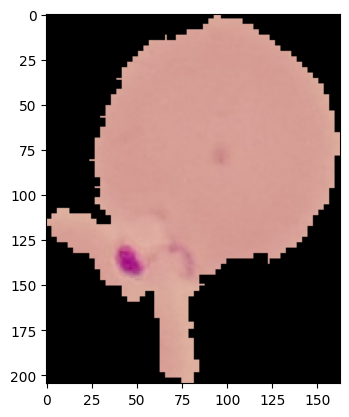

In [36]:
# Before image generation
plt.imshow(para_img);

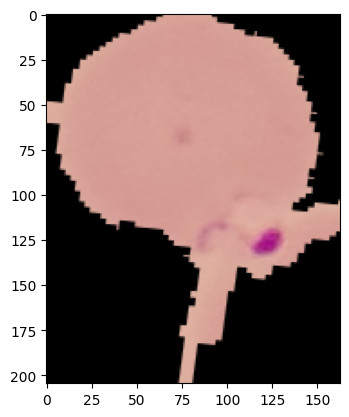

In [37]:
# After image generation
plt.imshow(image_gen.random_transform(para_img)); # Since it applies rangom image generation, each time we obtain a different image. 

In [38]:
image_gen.flow_from_directory(train_path) 
# applyng to the train data
# Instead of loading the images completely into memory, it generates data in **batches** (small groups).
# This allows large datasets to be processed without exceeding memory limits.
# By looking at the folder structure on the disk, it generates labeled and **batch-augmented data streams** for classification and 
# prepares it for training the model.


Found 24958 images belonging to 2 classes.


In [39]:
image_gen.flow_from_directory(test_path) 
# applying to test data

Found 2600 images belonging to 2 classes.


* Our data set **ready** for CNN model

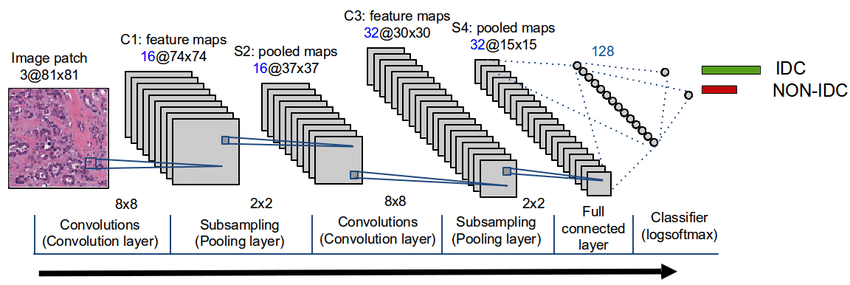

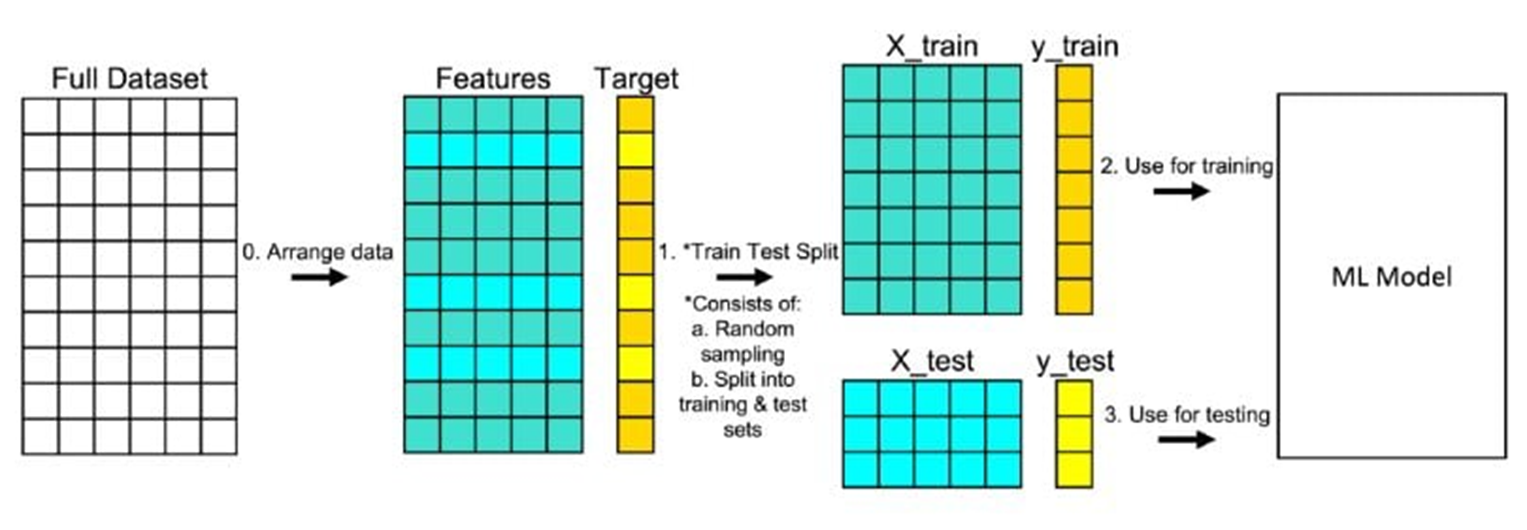

# Creating the CNN Model

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

About the architecture below:

* The first **Conv2D** layer works with 16 filters.

  * This means enough filters for extracting basic features (edges, textures, etc.) from the image.
  * A kernel size of (3x3) is a typical and effective choice.
  * With padding 'same', the output size is kept the same as the input size.

* The first **MaxPooling2D (2x2)** layer reduces the spatial dimensions by half (e.g., 130x130 → 65x65).

  * This reduces the computational load and provides a more summarized version of the features.

* The second **Conv2D** layer increases the number of filters to 32.

  * This allows for the extraction of more complex features.
  * The same 3x3 kernel and 'same' padding are used.

* The second **MaxPooling2D (2x2)** again halves the spatial dimensions.

Suggestions:

* Increasing the number of filters in each convolutional layer is a good practice.
* Increases like 16 → 32 → 64 allow the model to learn deeper and more complex features.
* If you activate a third layer, the model's capacity and generalization power increase, but the computational cost will rise.
* Dropout layers can be added to prevent overfitting.


In [41]:
model = Sequential()

model.add(Conv2D(filters=16, kernel_size=(3,3),input_shape=image_shape, padding='same', activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2))) # (2,2)--> Devides by 2; (3,3)--> Devides by 3
#model.add(Dropout(0.3))

model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))
#model.add(Dropout(0.3))

#model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu',))
#model.add(MaxPooling2D(pool_size=(2, 2)))
#model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
#model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid')) # Binary classification

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 130, 130, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 65, 65, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 65, 65, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,102,369 (8.02 MB)

 Trainable params: 2,102,369 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

Factors such as using fewer filters, selecting smaller filter sizes, or using dropout help keep the number of parameters low.

The different applications in the processes here (by also considering the subsequent neural networks) help us get a glimpse of the **Black Box**.
We can observe what is effective to what extent, etc.


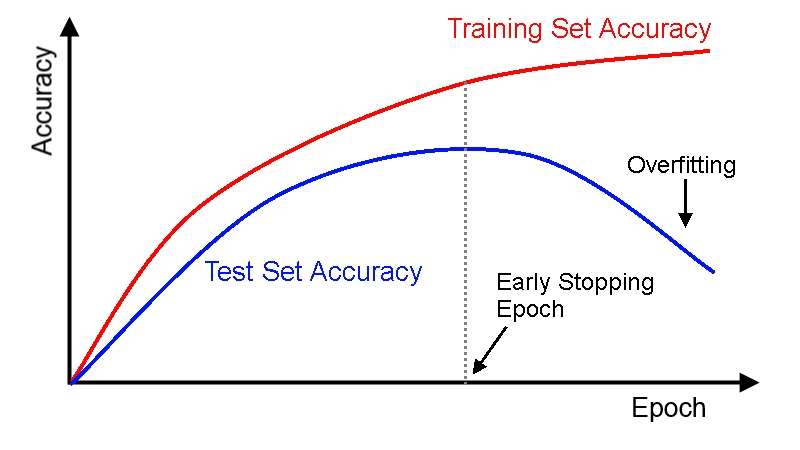

* If curves seperate each other model goes to overfitting. **Early stopping prevents overfitting**.

## Early Stopping

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

In [44]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

## Training the Model

### Image Generation for Train Data

In [45]:
# In the 1st and 2nd Neural Networks, Image Generation is applied to both the train and test data.
# However, in the 3rd and 4th Neural Networks, Image Generation has not been applied to the test data.


In [46]:
# Apply image generator to train data

In [47]:
# help(image_gen.flow_from_directory)

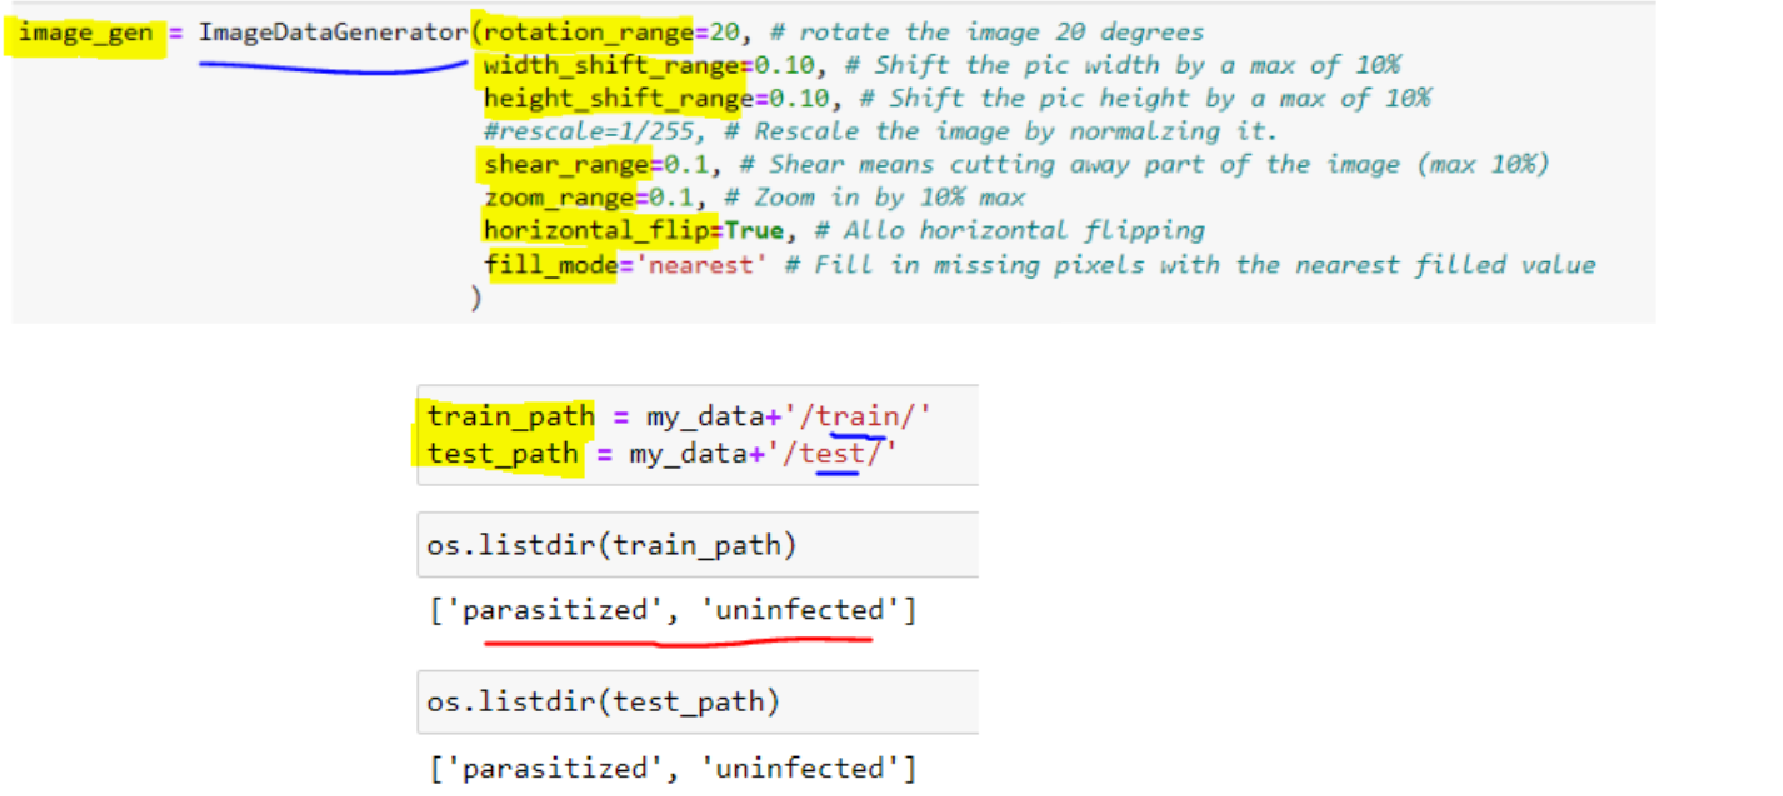

we had performed the following operations above

In [48]:
# Using the "image\_gen" process shown in the image above and the information in the "train\_path" section of the image above,
# we perform the transformation process below. We apply the transformation to all images.

batch_size = 32
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=(130,130),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary', shuffle=True, seed=42)

Found 24958 images belonging to 2 classes.


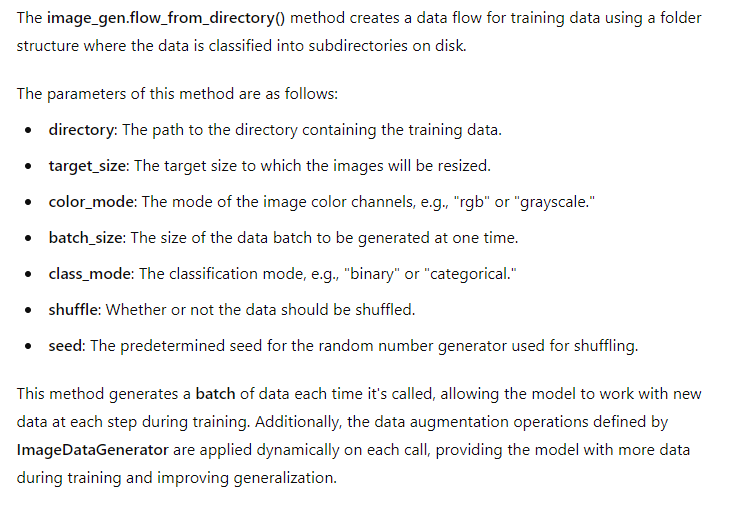

**Image Generator:**
This function reads the image files located in a specific directory, applies some predefined transformations, and prepares these images in batches to feed into your model. This code does not increase the amount or size of the dataset. However, the dataset size can be increased by applying data augmentation techniques. Currently, the code only ensures that the dataset is read, resized, and processed. Unless data augmentation techniques are applied, the size or amount of your dataset will not change.


### Image Generation for Test Data

In [49]:
test_image_gen = image_gen.flow_from_directory(test_path,
                                               target_size=(130,130),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary', shuffle=True, seed=42)

Found 2600 images belonging to 2 classes.


**!!! NOTE: !!!** In fact, we don't need to apply **"image_gen"** to our test data; it can be applied to the training data for better learning. However, for the test data, we can test with the **original data**. Above, we applied it to the test data as well, but if we didn't want to apply it, we could define a separate **ImageDataGenerator()** for the test data and proceed as follows:

image_gen_test = ImageDataGenerator()

test_image_gen = image_gen_test.flow_from_directory(test_path,

                                               target_size=(130,130),
                                               
                                               color_mode='rgb',
                                               
                                               batch_size=batch_size,
                                               
                                               class_mode='binary', shuffle=True, seed=42)
                   
                   
                                               
* If your accuracy result is not good, you can change as "**shuffle=False**"
* The **shuffle=True** parameter in the flow\_from\_directory function ensures that the images in the dataset are shuffled randomly. This is important for the model to generalize better during training.
  **shuffle=True**: The data is shuffled, and the model's generalization improves.
  **shuffle=False**: The data is not shuffled, and the model is trained with ordered data. The preferred version is the one where True is selected.


In [50]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [51]:
test_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [52]:
results = model.fit(train_image_gen,epochs=10,
                    validation_data=test_image_gen,
                    callbacks=[early_stop])

Epoch 1/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 314s 401ms/step - accuracy: 0.6302 - loss: 23.4249 - val_accuracy: 0.8538 - val_loss: 0.3666
Epoch 2/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 126s 161ms/step - accuracy: 0.8860 - loss: 0.3140 - val_accuracy: 0.8992 - val_loss: 0.2797
Epoch 3/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 122s 156ms/step - accuracy: 0.9083 - loss: 0.2838 - val_accuracy: 0.9227 - val_loss: 0.2401
Epoch 4/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 121s 155ms/step - accuracy: 0.9232 - loss: 0.2397 - val_accuracy: 0.9238 - val_loss: 0.2302
Epoch 5/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 128s 165ms/step - accuracy: 0.9193 - loss: 0.2864 - val_accuracy: 0.9235 - val_loss: 0.2348
Epoch 6/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 130s 167ms/step - accuracy: 0.9205 - loss: 0.2479 - val_accuracy: 0.9323 - val_loss: 0.2067
Epoch 7/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 137s 175ms/step - accuracy: 0.9233 - loss: 0.2326 - val_accuracy: 0.9012 - val_loss: 0.2701
Epoch 8/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 129s 166ms/step - accuracy: 0.9303 

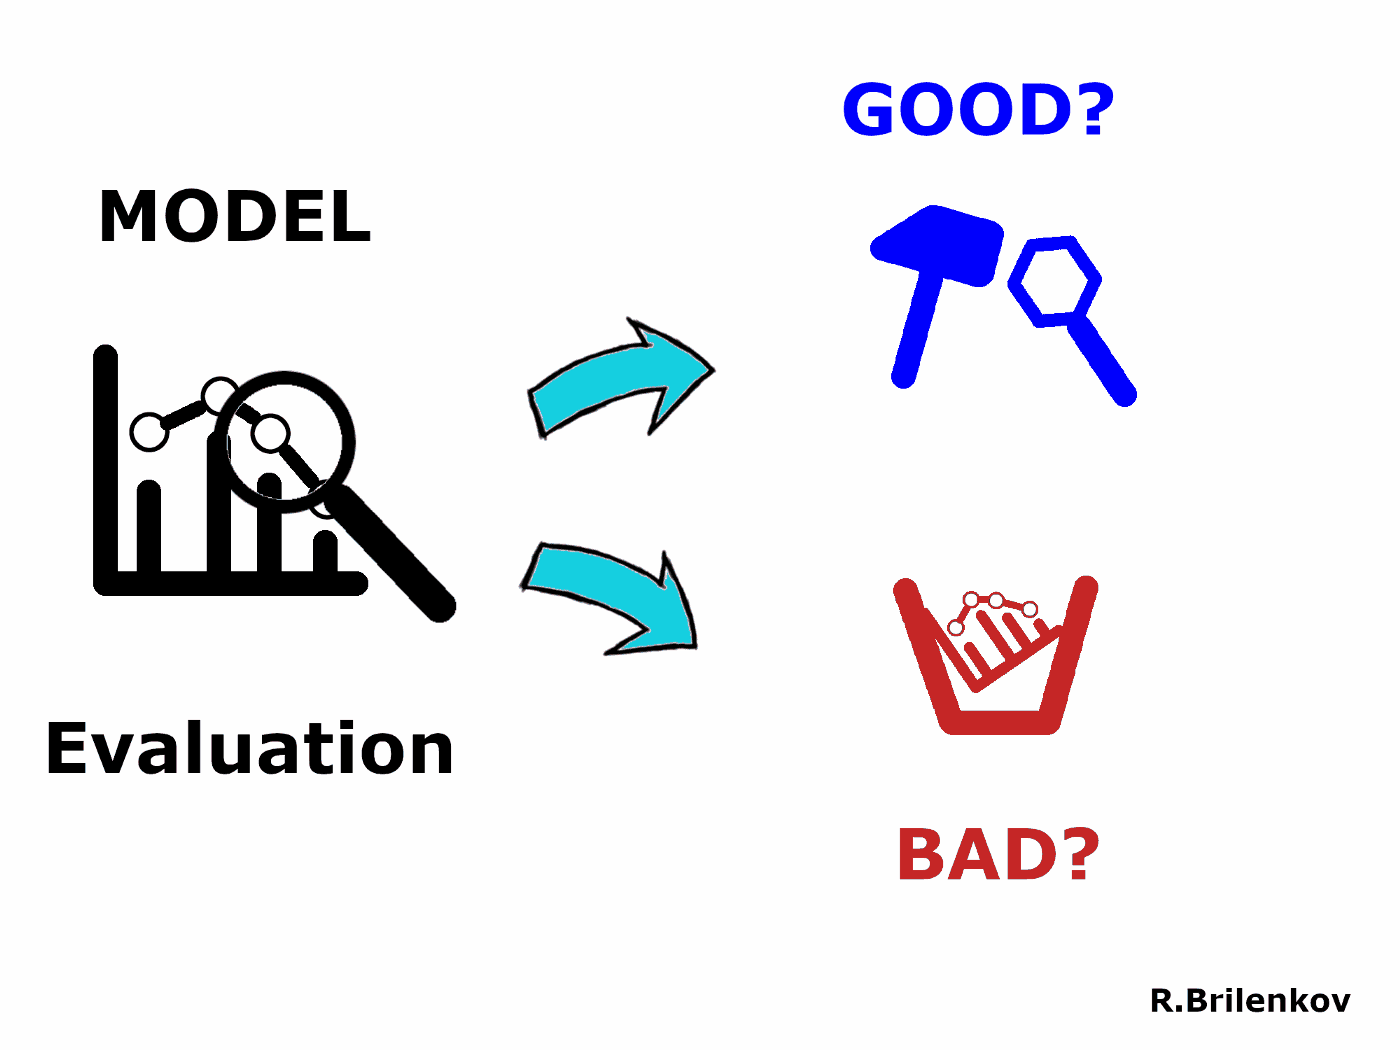

## Evaluating the Model

In [53]:
summary = pd.DataFrame(model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.717966,4.609175,0.853846,0.366616
1,0.899351,0.288616,0.899231,0.279735
2,0.912894,0.273135,0.922692,0.240124
3,0.921829,0.242741,0.923846,0.230230
4,0.921348,0.262730,0.923462,0.234757


In [54]:
summary.tail()

,accuracy,loss,val_accuracy,val_loss
5,0.922149,0.241799,0.932308,0.206740
6,0.927478,0.225176,0.901154,0.270129
7,0.932206,0.208622,0.895000,0.275813
8,0.928840,0.226562,0.938462,0.175446
9,0.930804,0.203995,0.920769,0.244052


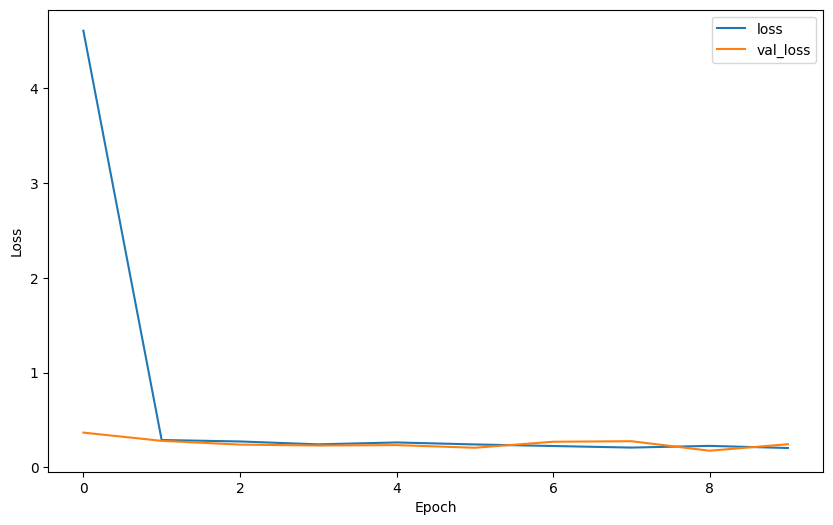

In [55]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

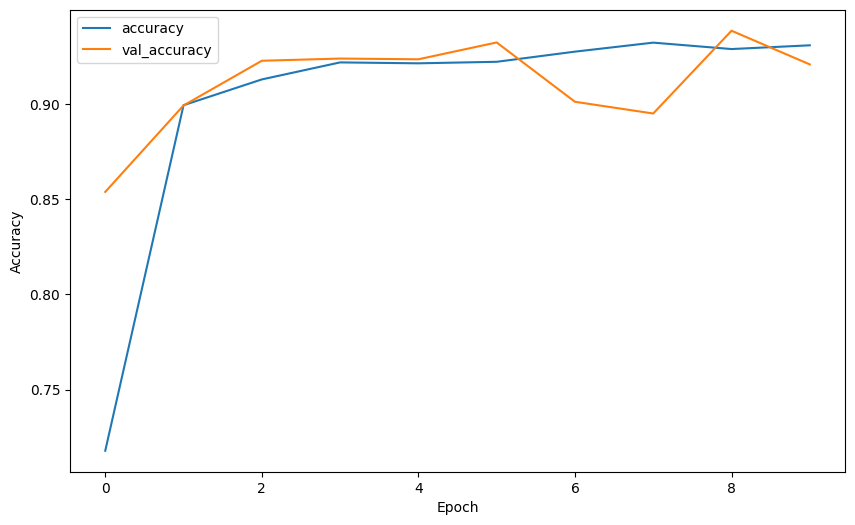

In [56]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()


First, I built a basic model: **2 Conv2D** and **2 MaxPooling** layers, and I saw a high score in the output. This means that my dataset is not very complex. If there is **overfitting**, I will add **Dropout** and **BatchNormalization** layers between the existing ones.


In [57]:
model.metrics_names

['loss', 'compile_metrics']

we should sample the images in the validation set exactly once(if you are planning to evaluate, you need to change the batch size of the valid generator to 1 or something that exactly divides the total num of samples in validation set), but the order doesn’t matter so let “shuffle” be True as it was earlier.

In [58]:
model.evaluate(test_image_gen)

82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 0.9246 - loss: 0.2330


[0.23431624472141266, 0.9238461256027222]

In [59]:
from tensorflow.keras.preprocessing import image

In [60]:
pred_probabilities = model.predict(test_image_gen)

82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step


In [61]:
pred_probabilities

array([[0.7743523 ],
       [0.01943889],
       [0.9605769 ],
       ...,
       [0.9845899 ],
       [0.9816767 ],
       [0.00342393]], dtype=float32)

In [62]:
test_image_gen.classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [63]:
pred_probabilities

array([[0.7743523 ],
       [0.01943889],
       [0.9605769 ],
       ...,
       [0.9845899 ],
       [0.9816767 ],
       [0.00342393]], dtype=float32)

In [64]:
predictions = pred_probabilities > 0.5

The expression **predictions = pred\_probabilities > 0.5** checks whether each value in a certain prediction probabilities array (**pred\_probabilities**) exceeds a specific threshold. In this case, the threshold is set to 0.5.
**If the predictions are greater than 0.5, they are considered as 1 (positive class), and if they are less than 0.5, they are considered as 0 (negative class).**

**To explain what the code does in more detail:**

**pred\_probabilities:** This is typically an array or list containing the predicted probabilities for each example, generated by a model. These probabilities usually range between 0 and 1.

**> 0.5:** This operator compares each probability value in the **pred\_probabilities** array to 0.5. If a value is greater than 0.5, the comparison is evaluated as True (Correct); if it is less than or equal to 0.5, it is evaluated as False (Incorrect).

**predictions:** This is a new array or list created as the result of the above comparison. This array contains boolean (True/False) values indicating whether each example exceeds the specified threshold.

This type of code is commonly used in binary classification problems, where the model predicts whether an example belongs to a certain class, and this expression is used to convert the predictions into binary (yes/no, positive/negative, etc.) results based on a specific threshold.


In [65]:
predictions[:100]

array([[ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [

In [66]:
from sklearn.metrics import classification_report,confusion_matrix

In [67]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.50      0.45      0.47      1300
           1       0.50      0.55      0.52      1300

    accuracy                           0.50      2600
   macro avg       0.50      0.50      0.50      2600
weighted avg       0.50      0.50      0.50      2600



In [68]:
confusion_matrix(test_image_gen.classes,predictions)

array([[581, 719],
       [589, 711]])

**COMMENT**:

The model's performance is quite low, struggling to correctly classify both positive and negative classes.

The numbers of false positives and false negatives are high.

This situation could be caused by the model's insufficient learning, data imbalance, or other issues during the training process.


## Save the Model

In [69]:
model.save('malaria_model_basic.h5')

* The code below is and alternative way for model loading (in the latest version, we save the model using the code below).

In [70]:
from tensorflow.keras.saving import save_model

save_model(model, 'malaria_model_basic.keras')

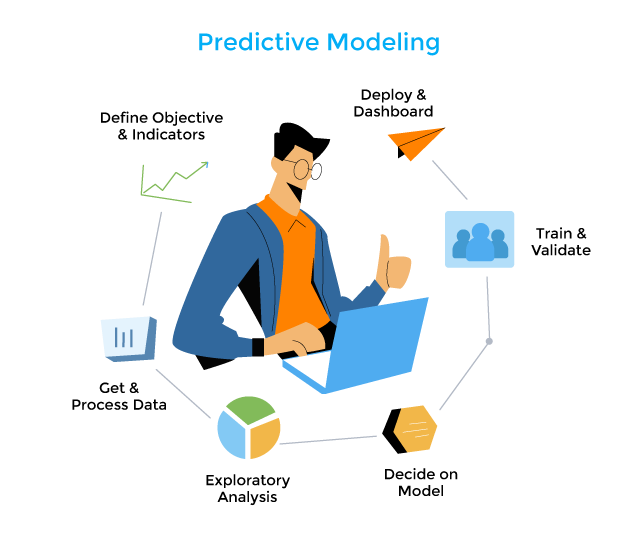

# Predicting on an Image

Various images of the sun were provided here to see if it would try to predict them... It was an experiment to see if it would resemble its own dataset.
First, a moon image, then a sun image.

In [71]:
para_cell

'cell_images/train/parasitized/C100P61ThinF_IMG_20150918_144823_cell_158.png'

In [72]:
my_image = image.load_img(para_cell,target_size=image_shape)

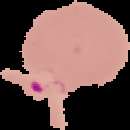

In [73]:
my_image

In [74]:
type(my_image)

PIL.Image.Image

In [75]:
my_image = image.img_to_array(my_image)

In [76]:
type(my_image)

numpy.ndarray

In [77]:
my_image.shape

(130, 130, 3)

**With the code below**; it is used to convert a single image into the batch format accepted by the model. This process transforms the image into a 4D numpy array with the shape (1, height, width, channels).


In [78]:
my_image = np.expand_dims(my_image, axis=0)

In [79]:
my_image.shape

(1, 130, 130, 3)

In [80]:
model.predict(my_image) # as the result is less than the threshold value, it was assigned to class 0 or negative

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([[0.00058109]], dtype=float32)

In [81]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [82]:
test_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [84]:
import numpy as np
import tensorflow as tf
from PIL import Image

# Load the Model
model = tf.keras.models.load_model('malaria_model_basic.keras')

# Open the new image and convert it to a suitable format.
image = Image.open("moon.jpg")
image = image.resize((130, 130))
image_array = np.array(image.convert('RGB')) / 255.0
image_array = np.expand_dims(image_array, axis=0) # Makes Tensor

# Predict
prediction = model.predict(image_array)

# Print the result
predicted_class = np.argmax(prediction)
print('Predicted Class:', predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Class: 0


This code snippet is used to **convert an image file** into a **numpy array**. The image file is first opened with the **Image** class, then converted to **RGB** format using the **convert** method. After that, the pixel values in the 0-255 range are scaled to the 0-1 range. The **expand_dims** method is used to increase the array's dimension by one, turning it into a **4-dimensional array** required for model prediction.

In [85]:
import numpy as np
import tensorflow as tf
from PIL import Image

# Load the Model
model = tf.keras.models.load_model('malaria_model_basic.keras')

# Open the new image and convert it to a suitable format.
image = Image.open(r"sun.jpeg")
image = image.resize((130, 130))
image_array = np.array(image.convert('RGB')) / 255.0
image_array = np.expand_dims(image_array, axis=0)

# Predict
prediction = model.predict(image_array)

# Print the predicted result
predicted_class = np.argmax(prediction)
print('Predicted Class:', predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Class: 0


In [86]:
import numpy as np
import tensorflow as tf
from PIL import Image

# Load the model
model = tf.keras.models.load_model('malaria_model_basic.keras')

# Open the new image and convert it to a suitable format.
image = Image.open("teest.png")
image = image.resize((130, 130))
image_array = np.array(image.convert('RGB')) / 255.0
image_array = np.expand_dims(image_array, axis=0)

# Predict
prediction = model.predict(image_array)

# Print the predicted result
predicted_class = np.argmax(prediction)
print('Predicted Class:', predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted Class: 0


A Solution of Malaria Dataset by one of our students in Kaggle

https://www.kaggle.com/code/fnurazman/malaria-cell-images-cnn-96-vgg16-resnet50-efnetb3#EfficientNetB3